# 1 4 24 lab meeting figs

In [2]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

# 0. co6 10/12/23, predicting CFA PCs

In [3]:
pre=100
post=100
session_path = '../data/co/co6/co6_10122023'
session = MPOptoClass(session_path, post=post)

love


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


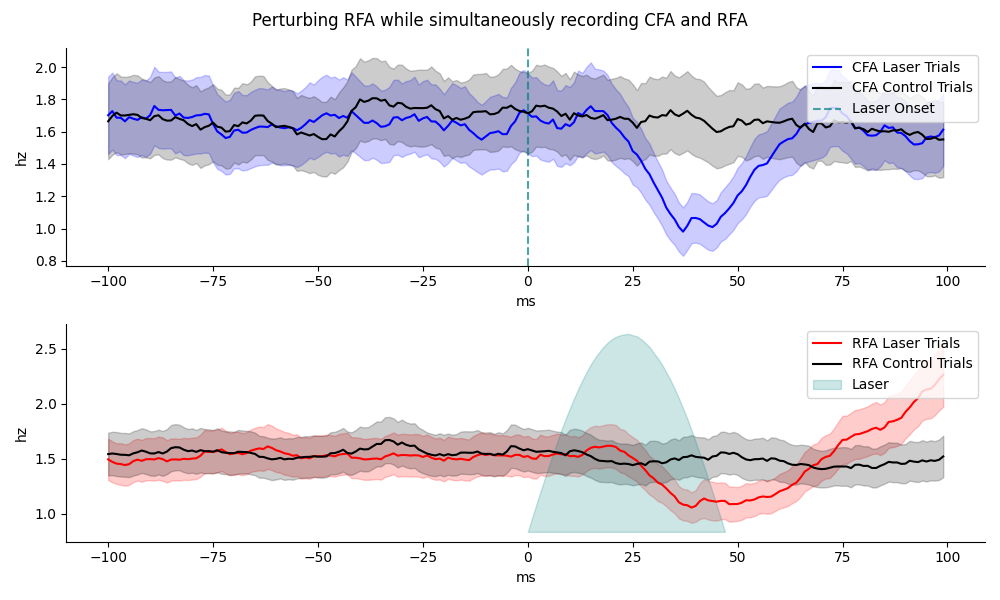

In [5]:
fs=1
pre=100

laser_bounds = copy.deepcopy(session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
ctrl_bounds[:,0] = ctrl_bounds[:,0] - pre

CFA_b, RFA_b = session.smoother(bounds=laser_bounds, sigma=10, binsize=fs, concat=False)
CFA_c, RFA_c = session.smoother(bounds=ctrl_bounds, sigma=10, binsize=fs, concat=False)

trial_length = CFA_b[0].shape[0]
num_trials = len(CFA_b)
num_ctrls = len(CFA_c)
num_neurons = CFA_b[0].shape[1]
num_climbing = np.sum(session.climbing_logical)

CFA_b = np.array(CFA_b)
RFA_b = np.array(RFA_b)
CFA_c = np.array(CFA_c)
RFA_c = np.array(RFA_c)

highlaser_idx = np.squeeze(np.where(np.array(session.laser['laser_powers']) > 2.26))
start = laser_bounds[highlaser_idx[0],0]
end = laser_bounds[highlaser_idx[0],1]
laser_curve = session.laser['laser_ts'][start:end]
laser_curve = laser_curve[laser_curve>0.1]

CFA_sts_avgavg = np.average(CFA_b, axis=(0,2)) / (fs/1000)
temp = np.average(CFA_b, axis=0)
CFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

RFA_sts_avgavg = np.average(RFA_b, axis=(0,2)) / (fs/1000)
temp = np.average(RFA_b, axis=0)
RFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

CFA_ctrlsts_avgavg = np.average(CFA_c, axis=(0,2)) / (fs/1000)
temp = np.average(CFA_c, axis=0)
CFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

RFA_ctrlsts_avgavg = np.average(RFA_c, axis=(0,2)) / (fs/1000)
temp = np.average(RFA_c, axis=0)
RFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - pre

fig0, ax0 = plt.subplots(2, 1, figsize=(10,6))
ax0[0].plot(x, CFA_sts_avgavg, color='blue', label='CFA Laser Trials')
ax0[0].plot(x, CFA_ctrlsts_avgavg, color='black', label = 'CFA Control Trials')
ax0[0].fill_between(x, CFA_sts_avgavg - CFA_sts_avgsem, CFA_sts_avgavg + CFA_sts_avgsem, color='blue', alpha=0.2)
ax0[0].fill_between(x, CFA_ctrlsts_avgavg - CFA_ctrlsts_avgsem, CFA_ctrlsts_avgavg + CFA_ctrlsts_avgsem, color='black', alpha=0.2)
ax0[0].axvline(0, color='teal', alpha=0.7, ls='--', label='Laser Onset')
ax0[0].set_ylabel('hz')
ax0[0].set_xlabel('ms')
ax0[0].legend(loc=1)

ax0[1].plot(x, RFA_sts_avgavg, color='red', label='RFA Laser Trials')
ax0[1].plot(x, RFA_ctrlsts_avgavg, color='black', label='RFA Control Trials')
ax0[1].fill_between(x, RFA_sts_avgavg - RFA_sts_avgsem, RFA_sts_avgavg + RFA_sts_avgsem, color='red', alpha=0.2)
ax0[1].fill_between(x, RFA_ctrlsts_avgavg - RFA_ctrlsts_avgsem, RFA_ctrlsts_avgavg + RFA_ctrlsts_avgsem, color='black', alpha=0.2)
rfa_ymin = ax0[1].get_ylim()[0]
rfa_ymax = ax0[1].get_ylim()[1]
rfa_laser = normalizeDataToRange(laser_curve, (rfa_ymin, rfa_ymax))
rfa_laser_x = np.arange(0,48)
ax0[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2, label='Laser')
#rfa_ymin = ax1b[1].get_ylim()[0]
#rfa_ymax = ax1b[1].get_ylim()[1]
#rfa_laser = normalizeDataToRange(laser_curve, (rfa_ymin, rfa_ymax))
#rfa_laser_x = np.arange(0,4.8,.1)
#ax1b[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2)
ax0[1].legend(loc=1)
ax0[1].set_xlabel('ms')
ax0[1].set_ylabel('hz')

ax0[0].spines['top'].set_visible(False)
ax0[0].spines['right'].set_visible(False)
ax0[1].spines['top'].set_visible(False)
ax0[1].spines['right'].set_visible(False)
fig0.suptitle('Perturbing RFA while simultaneously recording CFA and RFA')


fig0.tight_layout()
#fig1b.savefig('../results/fig1.pdf')

In [91]:
num_PCs = 50

omitLaserBounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds)

(climbing_nlags_PCA, climbing_cut_PCA), pca_objs  = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10, num_PCs = num_PCs)
climbing_cfa_PCA = climbing_cut_PCA[:, :num_PCs]


laser_nlags_PCA, laser_cut_PCA = session.transformat(pca_objs, bounds=laser_bounds, num_PCs=num_PCs, binsize=10, nlags=10)
laser_cfa_PCA = laser_cut_PCA[:,:num_PCs]

ctrl_nlags_PCA, ctrl_cut_PCA = session.transformat(pca_objs, bounds=ctrl_bounds, num_PCs=num_PCs, binsize=10, nlags=10)
ctrl_cfa_PCA = ctrl_cut_PCA[:,:num_PCs]

true_y, predic_y, predic_std, h = wiener_kfolds(climbing_nlags_PCA, climbing_cfa_PCA, c=(2,5), sweep='log') 
climbing_score = weighted_r2(true_y, predic_y)
predic_laser = test_wiener_filter(laser_nlags_PCA, h)
laser_score = weighted_r2(laser_cfa_PCA, predic_laser)
predic_ctrl = test_wiener_filter(ctrl_nlags_PCA, h)
ctrl_score = weighted_r2(ctrl_cfa_PCA, predic_ctrl)


0it [00:00, ?it/s]

best_c: 10000.0


1it [00:05,  5.11s/it]

best_c: 10000.0


2it [00:10,  5.12s/it]

best_c: 10000.0


3it [00:15,  5.12s/it]

best_c: 10000.0


4it [00:20,  5.12s/it]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


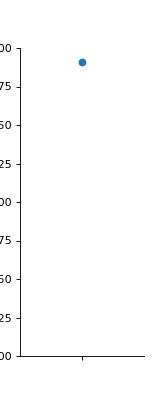

In [89]:
fig1, ax1 = plt.subplots()
ax1.scatter('     ',ctrl_score)
ax1.set_ylim([0,.2])

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#fig1.savefig('../results/miri_labmeeting_01042024/fig1.pdf')

In [53]:
window_scores = []
window = 2000
iterator = np.arange(0, true_y.shape[0], window)
for i in range(len(iterator)-1):
    temp1 = true_y[iterator[i]:iterator[i+1], 0]
    temp2 = predic_y[iterator[i]:iterator[i+1], 0]
    window_scores.append(r2_score(temp1, temp2))
window_scores = np.array(window_scores)
print(np.max(window_scores))
best_window = iterator[np.argmax(window_scores)]
print(best_window)
    

0.20085087040240512
4000


0.11476821351791566


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


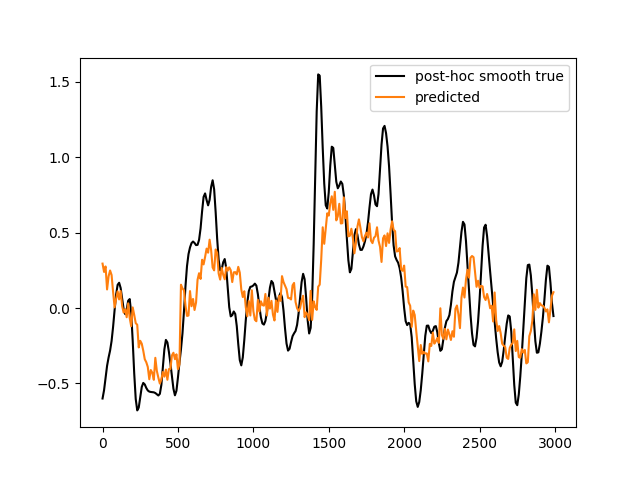

In [76]:
fig2, ax2 = plt.subplots()
y1=true_y[13700:14000, 0]
y2=predic_y[13700:14000, 0]
smooth_y1 = gaussian_filter1d(y1, sigma=2)
x = np.arange(y1.shape[0]) * 10
ax2.plot(x, smooth_y1, c='black', label='post-hoc smooth true')
ax2.plot(x, y2, c='tab:orange', label='predicted')
ax2.legend()
print(r2_score(true))

# contains fitting CFA vs RFA PCs for MP datasets/Reaching datsets, and network modelling of opto for new CFA inactivation, dual CFA/RFA recording animals CO7 and CO9


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


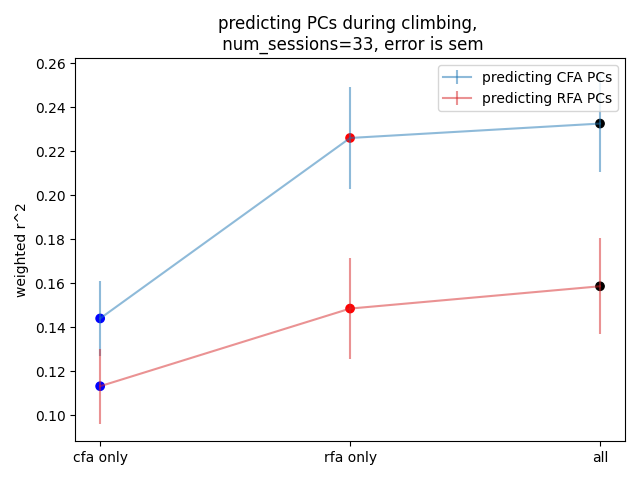

In [4]:
fig0, ax0 = plt.subplots()
labels = ['cfa only', 'rfa only', 'all']
num_sessions = len(allrfa_list)


ax0.errorbar(labels, [cfacfa, rfacfa, allcfa], yerr=[cfacfa_sem, rfacfa_sem, allcfa_sem], fmt='-', color='tab:blue', alpha=0.5, label='predicting CFA PCs')
ax0.scatter(labels, [cfacfa, rfacfa, allcfa], color=['blue', 'red', 'black'])
ax0.errorbar(labels, [cfarfa, rfarfa, allrfa], yerr=[cfacfa_sem, rfacfa_sem, allcfa_sem], fmt='-', color='tab:red', alpha=0.5, label='predicting RFA PCs')
ax0.scatter(labels, [cfarfa, rfarfa, allrfa], color=['blue', 'red', 'black'])
ax0.legend()
ax0.set_title(f'predicting PCs during climbing, \n num_sessions={num_sessions}, error is sem')
ax0.set_ylabel('weighted r^2')
fig0.tight_layout()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


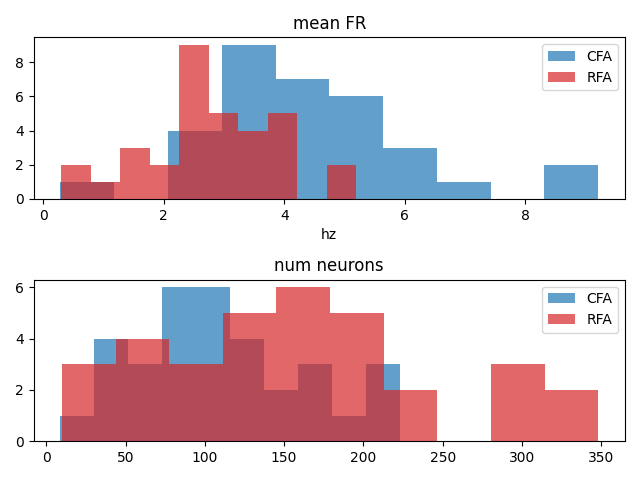

In [5]:
fig01, ax01 = plt.subplots(nrows=2)
ax01[0].hist(CFA_FRs, color='tab:blue', alpha=0.7, label='CFA')
ax01[0].hist(RFA_FRs, color='tab:red', alpha=0.7, label='RFA')
ax01[0].set_title('mean FR')
ax01[0].set_xlabel('hz')
ax01[0].legend()

ax01[1].hist(CFA_num_list, color='tab:blue', alpha=0.7, label='CFA')
ax01[1].hist(RFA_num_list, color='tab:red', alpha=0.7, label='RFA')
ax01[1].legend()
ax01[1].set_title('num neurons')
fig01.tight_layout()

# 1. predicting PCs during reaching

# some analysis of new data

In [6]:
rr_output = pload('../picklejar/rrCortFit_k4.pickle')
cfacfa_list=[]
rfacfa_list=[]
allcfa_list=[]

cfarfa_list = []
rfarfa_list = []
allrfa_list = []

CFA_FRs_list = []
RFA_FRs_list = []
CFA_num_list = []
RFA_num_list = []


for o in rr_output:
    if o == 0:
        print('failure!')
    else:
        num_CFA = o['num_CFA']
        num_RFA = o['num_RFA']
        
        (temp1, temp2) = o['all']
        allcfa_list.append(weighted_r2(temp1[:, :num_CFA], temp2[:, :num_CFA]))
        allrfa_list.append(weighted_r2(temp1[:, num_CFA:], temp2[:, num_CFA:]))
        
        (temp1, temp2) = o['cfa_only']
        
        cfacfa_list.append(weighted_r2(temp1[:,:num_CFA], temp2[:,:num_CFA]))
        cfarfa_list.append(weighted_r2(temp1[:,num_CFA:], temp2[:, num_CFA:]))
                           
        (temp1, temp2) = o['rfa_only']
        
        rfacfa_list.append(weighted_r2(temp1[:,:num_CFA], temp2[:,:num_CFA]))
        rfarfa_list.append(weighted_r2(temp1[:,num_CFA:], temp2[:, num_CFA:]))       
       
        temp1, temp2 = o['mean_FRs']
        CFA_FRs_list.append(temp1)
        RFA_FRs_list.append(temp2)
        CFA_num_list.append(o['num_CFA'])
        RFA_num_list.append(o['num_RFA'])
    
cfacfa = np.average(cfacfa_list)
cfacfa_sem = scipy.stats.sem(cfacfa_list)
rfacfa = np.average(rfacfa_list)
rfacfa_sem = scipy.stats.sem(rfacfa_list)
allcfa = np.average(allcfa_list)
allcfa_sem = scipy.stats.sem(allcfa_list)

cfarfa = np.average(cfarfa_list)
cfarfa_sem = scipy.stats.sem(cfarfa_list)
rfarfa = np.average(rfarfa_list)
rfarfa_sem = scipy.stats.sem(rfarfa_list)
allrfa = np.average(allrfa_list)
allrfa_sem = scipy.stats.sem(allrfa_list)

CFA_FRs = np.array(CFA_FRs_list) * 100
RFA_FRs = np.array(RFA_FRs_list) * 100

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


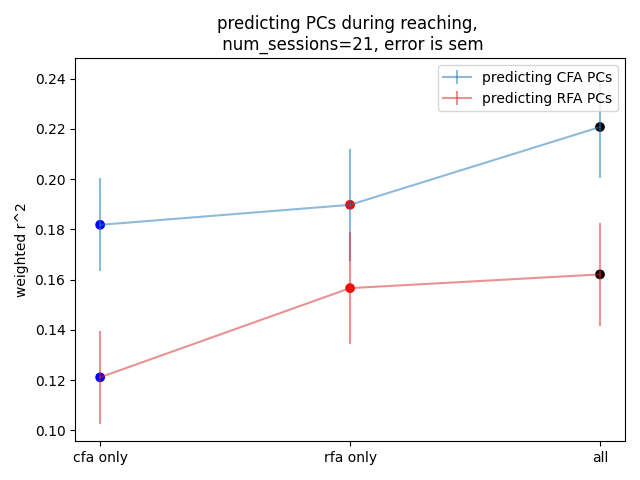

In [7]:
fig1, ax1 = plt.subplots()
labels = ['cfa only', 'rfa only', 'all']
num_sessions = len(allrfa_list)


ax1.errorbar(labels, [cfacfa, rfacfa, allcfa], yerr=[cfacfa_sem, rfacfa_sem, allcfa_sem], fmt='-', color='tab:blue', alpha=0.5, label='predicting CFA PCs')
ax1.scatter(labels, [cfacfa, rfacfa, allcfa], color=['blue', 'red', 'black'])
ax1.errorbar(labels, [cfarfa, rfarfa, allrfa], yerr=[cfacfa_sem, rfacfa_sem, allcfa_sem], fmt='-', color='tab:red', alpha=0.5, label='predicting RFA PCs')
ax1.scatter(labels, [cfarfa, rfarfa, allrfa], color=['blue', 'red', 'black'])
ax1.legend()
ax1.set_title(f'predicting PCs during reaching, \n num_sessions={num_sessions}, error is sem')
ax1.set_ylabel('weighted r^2')
fig1.tight_layout()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


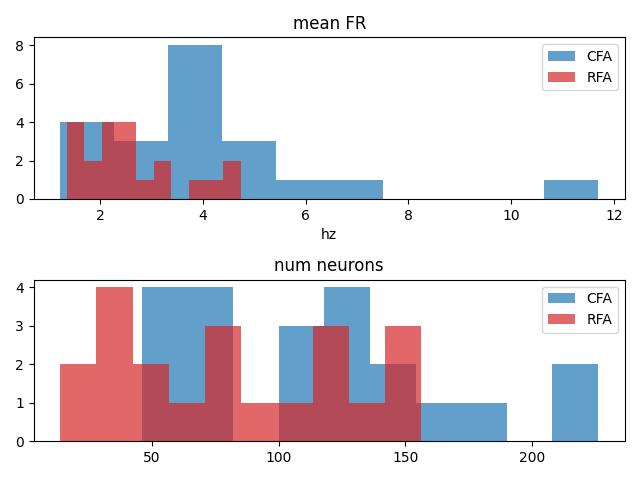

In [8]:
fig11, ax11 = plt.subplots(nrows=2)
ax11[0].hist(CFA_FRs, color='tab:blue', alpha=0.7, label='CFA')
ax11[0].hist(RFA_FRs, color='tab:red', alpha=0.7, label='RFA')
ax11[0].set_title('mean FR')
ax11[0].set_xlabel('hz')
ax11[0].legend()

ax11[1].hist(CFA_num_list, color='tab:blue', alpha=0.7, label='CFA')
ax11[1].hist(RFA_num_list, color='tab:red', alpha=0.7, label='RFA')
ax11[1].legend()
ax11[1].set_title('num neurons')
fig11.tight_layout()

# 2. looking at two new cfa inactivate animals co7/co9

In [20]:
session_path = '../data/co/co9/co9_12122023'
opto_session = MPOptoClass(session_path, laser_channel=3)

love


In [21]:
fs=1
pre=100

laser_bounds = copy.deepcopy(opto_session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
ctrl_bounds = copy.deepcopy(opto_session.laser['ctrl_bounds'])
ctrl_bounds[:,0] = ctrl_bounds[:,0] - pre

CFA_b, RFA_b = opto_session.smoother(bounds=laser_bounds, sigma=10, binsize=fs, concat=False)
CFA_c, RFA_c = opto_session.smoother(bounds=ctrl_bounds, sigma=10, binsize=fs, concat=False)

trial_length = CFA_b[0].shape[0]
num_trials = len(CFA_b)
num_ctrls = len(CFA_c)
num_neurons = CFA_b[0].shape[1]
num_climbing = np.sum(opto_session.climbing_logical)

CFA_b = np.array(CFA_b)
RFA_b = np.array(RFA_b)
CFA_c = np.array(CFA_c)
RFA_c = np.array(RFA_c)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


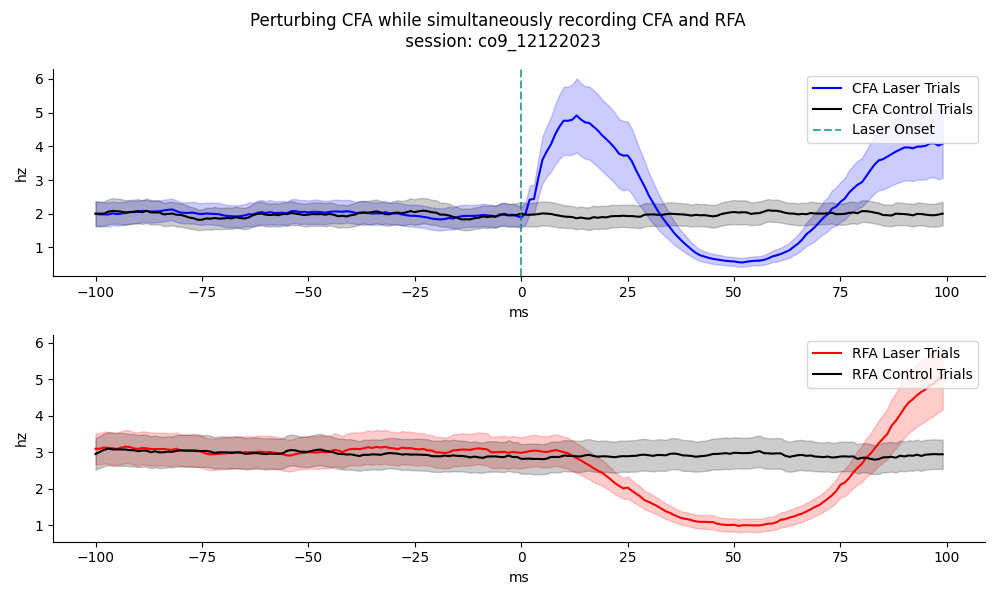

In [22]:
CFA_sts_avgavg = np.average(CFA_b, axis=(0,2)) / (fs/1000)
temp = np.average(CFA_b, axis=0)
CFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

RFA_sts_avgavg = np.average(RFA_b, axis=(0,2)) / (fs/1000)
temp = np.average(RFA_b, axis=0)
RFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

CFA_ctrlsts_avgavg = np.average(CFA_c, axis=(0,2)) / (fs/1000)
temp = np.average(CFA_c, axis=0)
CFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

RFA_ctrlsts_avgavg = np.average(RFA_c, axis=(0,2)) / (fs/1000)
temp = np.average(RFA_c, axis=0)
RFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - pre

fig1b, ax1b = plt.subplots(2, 1, figsize=(10,6))
ax1b[0].plot(x, CFA_sts_avgavg, color='blue', label='CFA Laser Trials')
ax1b[0].plot(x, CFA_ctrlsts_avgavg, color='black', label = 'CFA Control Trials')
ax1b[0].fill_between(x, CFA_sts_avgavg - CFA_sts_avgsem, CFA_sts_avgavg + CFA_sts_avgsem, color='blue', alpha=0.2)
ax1b[0].fill_between(x, CFA_ctrlsts_avgavg - CFA_ctrlsts_avgsem, CFA_ctrlsts_avgavg + CFA_ctrlsts_avgsem, color='black', alpha=0.2)
ax1b[0].axvline(0, color='teal', alpha=0.7, ls='--', label='Laser Onset')
ax1b[0].set_ylabel('hz')
ax1b[0].set_xlabel('ms')
ax1b[0].legend(loc=1)

ax1b[1].plot(x, RFA_sts_avgavg, color='red', label='RFA Laser Trials')
ax1b[1].plot(x, RFA_ctrlsts_avgavg, color='black', label='RFA Control Trials')
ax1b[1].fill_between(x, RFA_sts_avgavg - RFA_sts_avgsem, RFA_sts_avgavg + RFA_sts_avgsem, color='red', alpha=0.2)
ax1b[1].fill_between(x, RFA_ctrlsts_avgavg - RFA_ctrlsts_avgsem, RFA_ctrlsts_avgavg + RFA_ctrlsts_avgsem, color='black', alpha=0.2)
#rfa_ymin = ax1b[1].get_ylim()[0]
#rfa_ymax = ax1b[1].get_ylim()[1]
#rfa_laser = normalizeDataToRange(laser_curve, (rfa_ymin, rfa_ymax))
#rfa_laser_x = np.arange(0,4.8,.1)
#ax1b[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2)
ax1b[1].legend(loc=1)
ax1b[1].set_xlabel('ms')
ax1b[1].set_ylabel('hz')

ax1b[0].spines['top'].set_visible(False)
ax1b[0].spines['right'].set_visible(False)
ax1b[1].spines['top'].set_visible(False)
ax1b[1].spines['right'].set_visible(False)
fig1b.suptitle(f'Perturbing CFA while simultaneously recording CFA and RFA \n session: {opto_session.name}')


fig1b.tight_layout()
#fig1b.savefig('../results/fig1.pdf')

In [23]:
num_PCs = 50

omitLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, laser_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds)

(session.X, session.Y), pca_objs  = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10, num_PCs = num_PCs)
session.Y_CFA = session.Y[:, num_PCs:]

In [24]:
num_PCs = 50

omitLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, laser_bounds)
omitAllLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, ctrl_bounds)

(climbing_nlags_PCA, climbing_cut_PCA), climbing_PCObjs = opto_session.format_nlags_PCA(bounds=omitAllLaserBounds, binsize=10, nlags=10, num_PCs=num_PCs)
climbing_rfa_PCA = climbing_cut_PCA[:,num_PCs:]

laser_nlags_PCA, laser_cut_PCA = opto_session.transformat(climbing_PCObjs, bounds=laser_bounds, num_PCs=num_PCs, binsize=10, nlags=10)
laser_rfa_PCA = laser_cut_PCA[:,num_PCs:]
ctrl_nlags_PCA, ctrl_cut_PCA = opto_session.transformat(climbing_PCObjs, bounds=ctrl_bounds, num_PCs = num_PCs, binsize=10, nlags=10)

ctrl_rfa_PCA = ctrl_cut_PCA[:,num_PCs:]

true_y, predic_y, nada, h = wiener_kfolds(climbing_nlags_PCA, climbing_rfa_PCA, c=(2,5), sweep='log') 
climbing_score = weighted_r2(true_y, predic_y)
predic_laser = test_wiener_filter(laser_nlags_PCA, h)
laser_score = weighted_r2(laser_rfa_PCA, predic_laser)
predic_ctrl = test_wiener_filter(ctrl_nlags_PCA, h)
ctrl_score = weighted_r2(ctrl_rfa_PCA, predic_ctrl)

bounds too small for history


0it [00:00, ?it/s]

best_c: 21544.346900318822


1it [00:07,  7.86s/it]

best_c: 21544.346900318822


2it [00:16,  8.42s/it]

best_c: 21544.346900318822


3it [00:24,  8.12s/it]

best_c: 21544.346900318822


4it [00:32,  8.02s/it]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


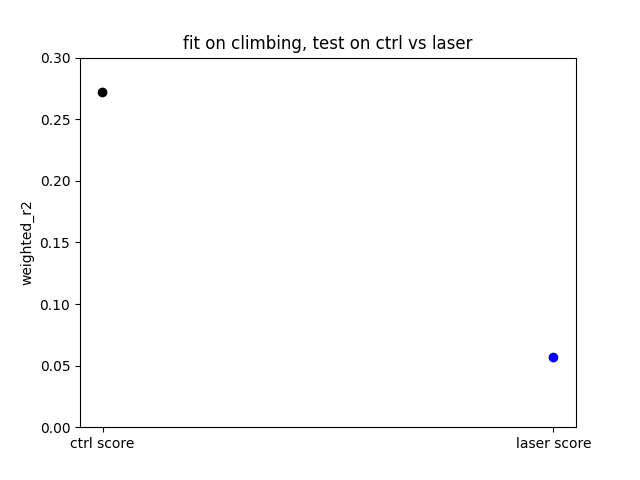

In [25]:
fig2, ax2 = plt.subplots()
ax2.scatter(['ctrl score', 'laser score'], [ctrl_score, laser_score], color=['black', 'blue'])
#ax2.plot(['climb xval score', 'ctrl score', 'laser score'], [climbing_score, ctrl_score, laser_score])
ax2.set_title('fit on climbing, test on ctrl vs laser')
ax2.set_ylabel('weighted_r2')
ax2.set_ylim([0,.3])
fig2.savefig('../results/fig2.pdf')


# are stims enough to make the model fit better?

In [27]:
num_PCs=50
pre=100
#(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=0)
#all_cut_CFAPCA = all_cut_PCA[:, :session.num_CFA]

laser_bounds = copy.deepcopy(opto_session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8)

omitTestLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, test_lasers)
omitAllLaserBounds = omitBoundInBounds(omitTestLaserBounds, train_lasers)

(climb_nlags_PCA, climb_cut_PCA), climb_PCObjs = opto_session.format_nlags_PCA(bounds=omitAllLaserBounds, binsize=10, nlags=10, num_PCs=num_PCs)
climb_RFA_PCA = climb_cut_PCA[:, num_PCs:]

(laser_nlags_PCA, laser_cut_PCA), laser_PCObjs = opto_session.format_nlags_PCA(bounds=omitTestLaserBounds, binsize=10, nlags=10, num_PCs=num_PCs)
laser_RFA_PCA = laser_cut_PCA[:, num_PCs:]

climb_true_y, climb_predic_y, climb_h = wiener_kfolds(climb_nlags_PCA, climb_RFA_PCA, c=(2,5), sweep='log') 
laser_true_y, laser_predic_y, laser_h = wiener_kfolds(laser_nlags_PCA, laser_RFA_PCA, c=(2,5), sweep='log') 

climbtest_nlags_PCA, climbtest_cut_PCA = opto_session.transformat(climb_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=10, nlags=10)
climbtest_RFA_PCA = climbtest_cut_PCA[:, num_PCs:]
lasertest_nlags_PCA, lasertest_cut_PCA = opto_session.transformat(laser_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=10, nlags=10)
lasertest_RFA_PCA = lasertest_cut_PCA[:, num_PCs:]

climbtest_predic_y = test_wiener_filter(climbtest_nlags_PCA, climb_h)
lasertest_predic_y = test_wiener_filter(lasertest_nlags_PCA, laser_h)

climb_xval_score = weighted_r2(climb_true_y, climb_predic_y)
laser_xval_score = weighted_r2(laser_true_y, laser_predic_y)

climb_test_score = weighted_r2(climbtest_RFA_PCA, climbtest_predic_y)
laser_test_score = weighted_r2(lasertest_RFA_PCA, lasertest_predic_y)


bounds too small for history
bounds too small for history


0it [00:00, ?it/s]

best_c: 21544.346900318822


1it [00:09,  9.00s/it]

best_c: 21544.346900318822


...

2it [00:17,  8.79s/it]

best_c: 21544.346900318822


3it [00:26,  8.70s/it]

best_c: 21544.346900318822


4it [00:34,  8.53s/it]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'predicting held out lasers, w/ laser training vs without')

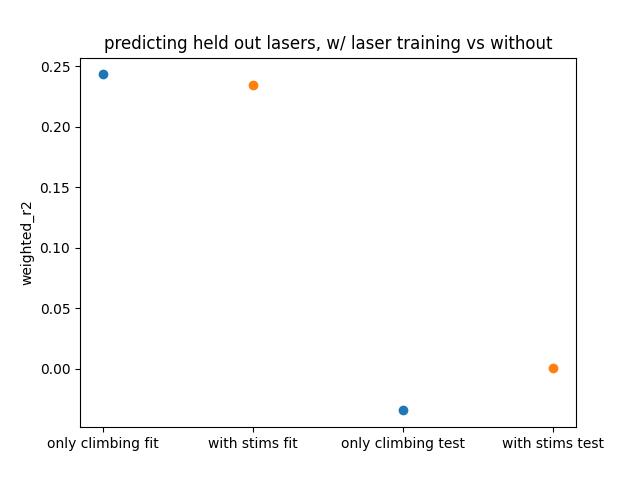

In [28]:
fig21, ax21 = plt.subplots()
ax21.scatter(['only climbing fit'], climb_xval_score, color='tab:blue', label='trained on only climbing')
ax21.scatter(['with stims fit'], laser_xval_score, color='tab:orange', label='trained with stims')
ax21.scatter(['only climbing test'], climb_test_score, color='tab:blue')
ax21.scatter(['with stims test'], laser_test_score, color='tab:orange')
ax21.set_ylabel('weighted_r2')
ax21.set_title('predicting held out lasers, w/ laser training vs without')

In [29]:
mod_train_lasers_bounds, duration = reBoundInBounds(omitTestLaserBounds, train_lasers)
laser_logical = bounds2Logical(mod_train_lasers_bounds, duration=duration)
laser_logical_trials = unstitchSeams(laser_logical, getSeamsFromBounds(omitTestLaserBounds, binsize=1))
sw_list = []
sw_multiplier=5

for trial in laser_logical_trials:
    temp = bin_timeseries(trial, binsize=10)
    sw_list.append(format_single_array(temp))
    sw = (np.hstack(sw_list))[:-1]
    sw = (sw*sw_multiplier)+1

In [30]:
nada1, nada2, sw_h = wiener_swkfolds(laser_nlags_PCA, laser_RFA_PCA, sw=sw, c=(20000,100000), n_l2=5, sweep='linear')

0it [00:00, ?it/s]

0.13224675215890028
0.15293803491848684
0.15589381130004654
0.15327446565839786
0.14846907372784449
best_c: 60000.0


1it [01:16, 76.74s/it]

0.24535424859863916
0.2751461636569901
0.28148029948435144
0.2800380107434907
0.2752983933231758
best_c: 60000.0


2it [02:33, 76.69s/it]

0.23510225499147533
0.26529747705421436
0.27140478027124204
0.2694967359089731
0.2641862676414089
best_c: 60000.0


3it [03:46, 75.07s/it]

0.22830337298518577
0.2548850299830964
0.2582437858554228
0.25411160696546264
0.2469458579020166
best_c: 60000.0


4it [04:59, 74.84s/it]


In [31]:
sw_climb_predic_y = test_wiener_filter(laser_nlags_PCA, sw_h)
sw_test_predic_y = test_wiener_filter(lasertest_nlags_PCA, sw_h)
sw_climb_score = weighted_r2(laser_RFA_PCA, sw_climb_predic_y)
sw_test_score = weighted_r2(lasertest_RFA_PCA, sw_test_predic_y)
print(sw_climb_score)
print(sw_test_score)

0.22658891552449098
0.1357777345361784


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


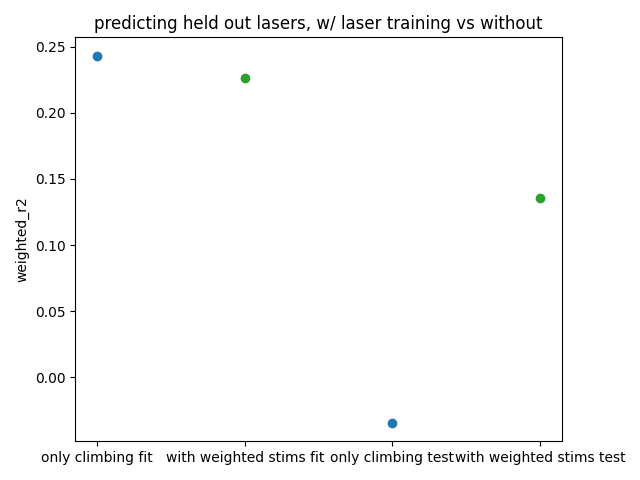

In [33]:
fig22, ax22 = plt.subplots()
ax22.scatter(['only climbing fit'], climb_xval_score, color='tab:blue', label='trained on only climbing')
#ax22.scatter(['with stims fit'], laser_xval_score, color='tab:orange', label='trained with stims')
ax22.scatter(['with weighted stims fit'], sw_climb_score, color='tab:green')
ax22.scatter(['only climbing test'], climb_test_score, color='tab:blue')
#ax22.scatter(['with stims test'], laser_test_score, color='tab:orange')
ax22.scatter(['with weighted stims test'], sw_test_score, color='tab:green')
ax22.set_ylabel('weighted_r2')
ax22.set_title('predicting held out lasers, w/ laser training vs without')
fig22.tight_layout()

In [3]:
session = MPOptoClass('../data/co/co9/co9_12122023', laser_channel=3) 
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepRegsco9.pickle')

love


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


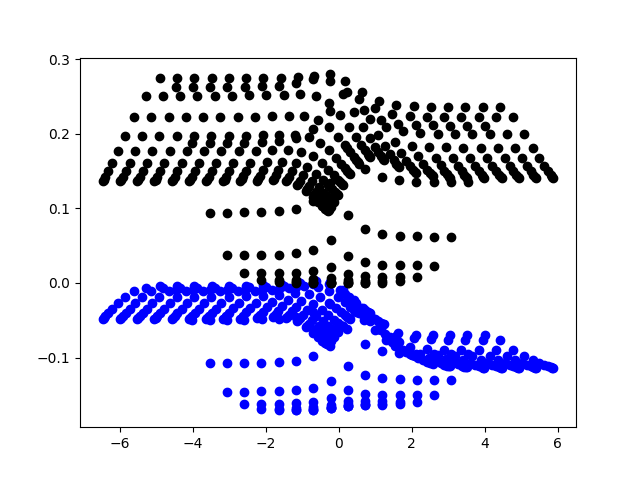

In [10]:
fig, ax = plt.subplots()
ratio_list = []
h_list = []
laser_score_list = []
ctrl_score_list = []
for idx, o in enumerate(output):
    h = o[0]
    laser_score = o[1]
    ctrl_score = o[2]
    
    temp = session.weights_per_region(h)
    ratio = np.log10(temp[0]/temp[1])
    
    ratio_list.append(ratio)
    h_list.append(h)
    laser_score_list.append(laser_score)
    ctrl_score_list.append(ctrl_score)
    
    ax.scatter(ratio, o[1], color='blue')
    ax.scatter(ratio, o[2], color='black')
#ax.legend()

In [12]:
reg_terms = np.logspace(0,9,20)
reg_combos = list(product(reg_terms, reg_terms))
laser_score_list = np.array(laser_score_list)
ctrl_score_list = np.array(ctrl_score_list)
ratio_list = np.array(ratio_list)

In [13]:
nada, bin_ratio_edges = np.histogram(ratio_list, bins=15)

laser_score_keep = []
ctrl_score_keep = []
ratio_keep = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = ratio_list > bin_ratio_edges[i]
    condition2 = ratio_list < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(laser_score_list[indices])
    temp1 = laser_score_list[indices]
    temp2 = temp1[keep]
    laser_score_keep.append(temp2)
    
    temp1 = ratio_list[indices]
    temp2 = temp1[keep]
    ratio_keep.append(temp2)
    
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(ctrl_score_list[indices])
    temp1 = ctrl_score_list[indices]
    temp2 = temp1[keep]
    ctrl_score_keep.append(temp2) 
    

In [37]:
a, b = opto_session.weights_per_region(sw_h, num_CFA=50)
sw_ratio = np.log10(a/b)
print(sw_ratio)

-0.024923128363484977


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


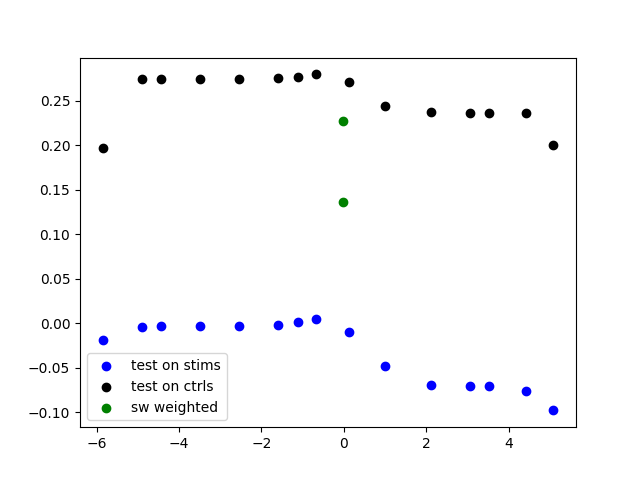

In [41]:
fig, ax = plt.subplots()
ax.scatter(ratio_keep, laser_score_keep, color='blue', label='test on stims')
ax.scatter(ratio_keep, ctrl_score_keep, color='black', label='test on ctrls')
ax.scatter(sw_ratio, sw_test_score, color='green', label='sw weighted')
ax.scatter(sw_ratio, sw_climb_score, color='green')
ax.legend()

In [36]:
a=np.power(np.arange(-30,30 ,5),3)

In [39]:
sweep = a+np.abs(a[0])
reg_combos = list(product(sweep, sweep))

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


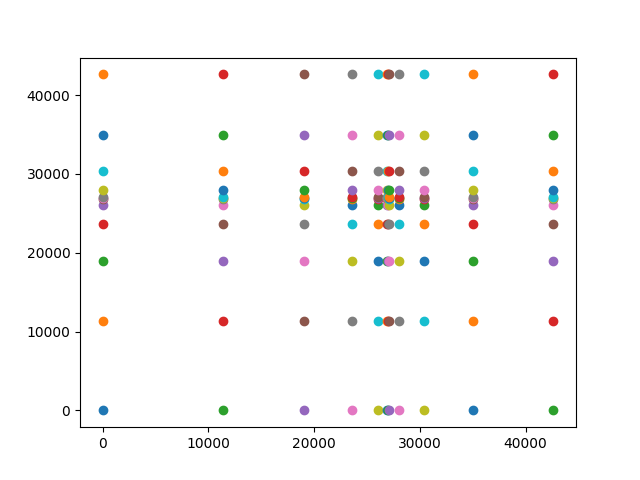

In [43]:
fig, ax = plt.subplots()
for combo in reg_combos:
    ax.scatter(combo[0], combo[1])